# Application

## GPAW
The [gpaw](https://gpaw.readthedocs.io/index.html) density-functional theory (DFT) simulation code provides a Python interface supporting the [message passing interface (MPI) for Python - mpi4py](https://mpi4py.readthedocs.io) for parallelization. So `executorlib` is used to orchestrate multiple [gpaw](https://gpaw.readthedocs.io/index.html) simulation each using multiple CPU cores for parallelization. These kind of hierarchical workflows are one of the core strength of `executorlib`. While the same could be achieved by writing the whole simulation workflow using [mpi4py](https://mpi4py.readthedocs.io) this would drastically increase the complexity. With `executorlib` the user can quickly up-scale their simulation workflow without the need to address the parallel execution explicitly, rather the parallelization is introduced on a per-function level, by submitting the functions to the `FluxClusterExecutor` or `FluxJobExecutor`.

In [1]:
import subprocess
from ase.build import bulk
from atomistics.workflows import (
    analyse_results_for_energy_volume_curve,
    get_tasks_for_energy_volume_curve,
)
import matplotlib.pyplot as plt
import pprint
from tqdm import tqdm
from time import sleep

/srv/conda/envs/notebook/lib/python3.13/site-packages/atomistics/workflows/__init__.py:77: UserWarning: PhonopyWorkflow(), QuasiHarmonicWorkflow(), get_band_structure(), get_dynamical_matrix(), get_hesse_matrix(), get_thermal_properties_for_harmonic_approximation(), get_tasks_for_harmonic_approximation(), analyse_results_for_harmonic_approximation(), get_tasks_for_quasi_harmonic_approximation(), analyse_results_for_quasi_harmonic_approximation(), get_thermal_properties_for_quasi_harmonic_approximation(), plot_band_structure() and plot_dos() are not available as the import of the module named 'structuretoolkit' failed.
  raise_warning(module_list=phonopy_workflows, import_error=e)


The only function which is executed using [mpi4py](https://mpi4py.readthedocs.io) is the `evaluate_with_gpaw()` function:

In [2]:
def evaluate_with_gpaw(task_dict, kpts, encut):
    import os
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["GPAW_MPI4PY"] = "1"

    from mpi4py import MPI
    from gpaw import GPAW, PW
    from gpaw.mpi4pywrapper import MPI4PYWrapper

    structure = task_dict["calc_energy"].copy()
    structure.calc = GPAW(
        xc="PBE",
        mode=PW(encut),
        kpts=kpts,
        communicator=MPI4PYWrapper(MPI.COMM_WORLD),
    )
    return structure.get_potential_energy()

As a first step of the workflow the equilibrium structure of four Aluminium atoms is strained by 5%.

In [3]:
task_dict = get_tasks_for_energy_volume_curve(
    structure=bulk("Al", a=4.03),
    num_points=7,
    vol_range=0.05,
    axes=("x", "y", "z"),
)

The resulting dictionary of structures `task_dict` is transformed to simplify the parallel execution:

In [4]:
task_loop_dict = {k: {"calc_energy": v} for k, v in task_dict["calc_energy"].items()}

The status of the flux cluster is validated using the `flux resource list` command and the `flux jobs -a` command, just to highlight flux was initialized correctly and has access to the available resources.

In [5]:
!flux resource list

     STATE NNODES NCORES NGPUS NODELIST
      free      1     16     0 jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
 allocated      0      0     0 
      down      0      0     0 


In [6]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO


### FluxClusterExecutor
The [FluxClusterExecutor](https://executorlib.readthedocs.io/en/latest/2-hpc-cluster.html#flux) is used in this demonstration primarily because flux can be installed on any workstation for testing. The [SlurmClusterExecutor](https://executorlib.readthedocs.io/en/latest/2-hpc-cluster.html#slurm) could be used analogously.

In [7]:
from executorlib import FluxClusterExecutor

The for each strained structure a calculation task is submitted to the `FluxClusterExecutor`. After the successful submission the current status of the flux queue is printed using `flux jobs -a`. Finally, the results are collected by gathering the [concurrent.futures.Future](https://docs.python.org/3/library/concurrent.futures.html#future-objects) objects.

In [8]:
future_dict = {}
with FluxClusterExecutor() as exe:
    for k, v in task_loop_dict.items():
        future_dict[k] = exe.submit(
            evaluate_with_gpaw, 
            task_dict=v, 
            kpts=(3, 3, 3), 
            encut=300,
            resource_dict={"cores": 2},
        )
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))
    result_dict = {
        k: f.result()
        for k, f in tqdm(future_dict.items())
    }
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))

['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒ7kyq7Ww jovyan   executorl+  R      1      1   0.123s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7hf6it7 jovyan   executorl+  R      1      1   0.255s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7eVGFwM jovyan   executorl+  R      1      1   0.380s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7bEyq9Z jovyan   executorl+  R      1      1   0.507s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7Y87LmV jovyan   executorl+  R      1      1   0.629s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7V4Cpx7 jovyan   executorl+  R      1      1   0.749s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7RrtNj1 jovyan   executorl+  R      1      1   0.874s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '']


100%|██████████| 7/7 [00:03<00:00,  2.02it/s]


['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒ7kyq7Ww jovyan   executorl+  F      1      1   4.536s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7eVGFwM jovyan   executorl+  F      1      1   4.685s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7hf6it7 jovyan   executorl+  F      1      1   4.499s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7bEyq9Z jovyan   executorl+  F      1      1   4.488s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7Y87LmV jovyan   executorl+  F      1      1   4.602s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7V4Cpx7 jovyan   executorl+  F      1      1   4.563s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7RrtNj1 jovyan   executorl+  F      1      1   4.425s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '']


The resulting energies for the different volumes are fitted using a 3rd order polynomial to derive the bulk modulus as second derivative multiplied by the equilibrium volume.

In [9]:
fit_dict = analyse_results_for_energy_volume_curve(
    output_dict={"energy": result_dict},
    task_dict=task_dict,
    fit_type="polynomial",
    fit_order=3,
)

The final energy volume curve plot summarizes the results of this calculation.

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2710/4024930470.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Volume [$\AA^3$]")


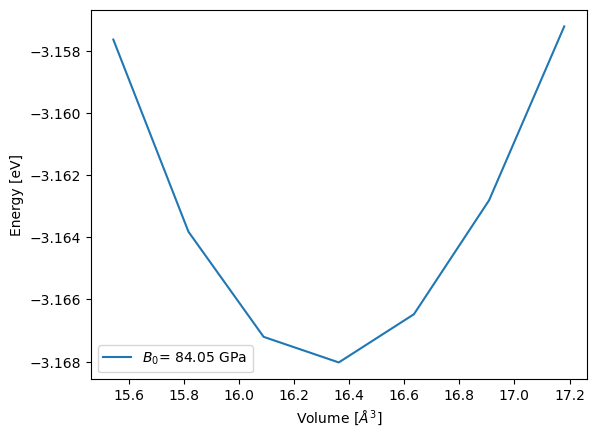

In [10]:
plt.plot(fit_dict["volume"], fit_dict["energy"], label="$B_0$= %0.2f GPa" % fit_dict["bulkmodul_eq"])
plt.xlabel("Volume [$\AA^3$]")
plt.ylabel("Energy [eV]")
plt.legend()

### FluxJobExecutor
In analogy to the [FluxClusterExecutor](https://executorlib.readthedocs.io/en/latest/2-hpc-cluster.html#flux) the [FluxJobExecutor](https://executorlib.readthedocs.io/en/latest/3-hpc-job.html#flux) can be applied to distribute simulation within a given queuing system allocation. The calculation of the bulk modulus with [gpaw](https://gpaw.readthedocs.io) is implemented in the same way.

In [11]:
from executorlib import FluxJobExecutor

The for each strained structure a calculation task is submitted to the `FluxJobExecutor`. After the successful submission the current status of the flux queue is printed using `flux jobs -a`. Finally, the results are collected by gathering the [concurrent.futures.Future](https://docs.python.org/3/library/concurrent.futures.html#future-objects) objects.

In [12]:
future_dict = {}
with FluxJobExecutor() as exe:
    for k, v in task_loop_dict.items():
        future_dict[k] = exe.submit(
            evaluate_with_gpaw, 
            task_dict=v, 
            kpts=(3, 3, 3), 
            encut=300,
            resource_dict={"cores": 2},
        )
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))
    result_dict = {
        k: f.result()
        for k, f in tqdm(future_dict.items())
    }
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))

['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒFAY12Hm jovyan   python      R      2      1   0.947s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFAV33j5 jovyan   python      R      2      1   0.947s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFAS55AP jovyan   python      R      2      1   0.948s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD4e jovyan   python      R      2      1   0.948s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD4d jovyan   python      R      2      1   0.948s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD4c jovyan   python      R      2      1   0.948s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD4b jovyan   python      R      2      1   0.949s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7kyq7Ww jovyan   executorl+  F      1      1   4.536s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7eVGF

100%|██████████| 7/7 [00:01<00:00,  3.86it/s]


['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒFAY12Hm jovyan   python      R      2      1   3.863s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFAV33j5 jovyan   python      R      2      1   3.863s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFAS55AP jovyan   python      R      2      1   3.864s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD4e jovyan   python      R      2      1   3.864s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD4d jovyan   python      R      2      1   3.864s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD4c jovyan   python      R      2      1   3.864s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD4b jovyan   python      R      2      1   3.866s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7kyq7Ww jovyan   executorl+  F      1      1   4.536s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒ7eVGF

The resulting energies for the different volumes are fitted using a 3rd order polynomial to derive the bulk modulus as second derivative multiplied by the equilibrium volume.

In [13]:
fit_dict = analyse_results_for_energy_volume_curve(
    output_dict={"energy": result_dict},
    task_dict=task_dict,
    fit_type="polynomial",
    fit_order=3,
)

The final energy volume curve plot summarizes the results of this calculation.

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2710/4024930470.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Volume [$\AA^3$]")


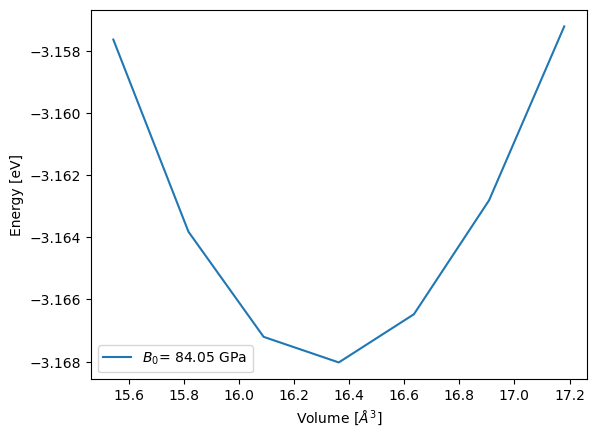

In [14]:
plt.plot(fit_dict["volume"], fit_dict["energy"], label="$B_0$= %0.2f GPa" % fit_dict["bulkmodul_eq"])
plt.xlabel("Volume [$\AA^3$]")
plt.ylabel("Energy [eV]")
plt.legend()

## Quantum Espresso
The [quantum espresso](https://www.quantum-espresso.org) density-functional theory (DFT) simulation code is written in Fortran and uses the message passing interface (MPI) for parallelization, without any Python bindings. So `executorlib` is used to orchestrate multiple [quantum espresso](https://www.quantum-espresso.org) simulation each using multiple CPU cores for parallelization. These kind of hierarchical workflows are one of the core strength of `executorlib`. It is important to emphasize that the same could not be achieved with other frameworks like [mpi4py](https://mpi4py.readthedocs.io) as [quantum espresso](https://www.quantum-espresso.org) does not support external MPI communicators without modifications to the Fortran source code. With `executorlib` the user can quickly up-scale their simulation workflow without the need to address the parallel execution explicitly, rather the parallelization is introduced on a per-function level, by submitting the functions to the `FluxClusterExecutor` or `FluxJobExecutor`.

In [15]:
import os
import subprocess
from ase.build import bulk
from atomistics.workflows import (
    analyse_results_for_energy_volume_curve,
    get_tasks_for_energy_volume_curve,
)
import matplotlib.pyplot as plt
import pprint
from tqdm import tqdm
from time import sleep

The function which handles the parallel execution is the `evaluate_with_quantum_espresso()` function, internally it calls `flux run pw.x` to execute the quantum espresso Fortran executable in parallel:

In [16]:
def evaluate_with_quantum_espresso(task_dict, pseudopotentials, kpts):
    from ase.calculators.espresso import Espresso, EspressoProfile
    from atomistics.calculators import evaluate_with_ase
    
    return evaluate_with_ase(
        task_dict=task_dict,
        ase_calculator=Espresso(
            pseudopotentials=pseudopotentials,
            tstress=True,
            tprnfor=True,
            kpts=kpts,
            profile=EspressoProfile(
                command="flux run pw.x",
                pseudo_dir="/home/jovyan/espresso/pseudo",
            ),
        ),
    )["energy"]

The pseudo potential is located in `~/espresso/pseudo`, here the absolute path to the pseudo potential is given as: `/home/jovyan/espresso/pseudo`.

In [17]:
pseudopotentials = {"Al": "Al.pbe-n-kjpaw_psl.1.0.0.UPF"}

As a first step of the workflow the equilibrium structure of four Aluminium atoms is strained by 5%.

In [18]:
task_dict = get_tasks_for_energy_volume_curve(
    structure=bulk("Al", a=4.15, cubic=True),
    num_points=7,
    vol_range=0.05,
    axes=("x", "y", "z"),
)

The resulting dictionary of structures `task_dict` is transformed to simplify the parallel execution:

In [19]:
task_loop_dict = {k: {"calc_energy": v} for k, v in task_dict["calc_energy"].items()}

The status of the flux cluster is validated using the `flux resource list` command and the `flux jobs -a` command, just to highlight flux was initialized correctly and has access to the available resources.

In [20]:
!flux resource list

     STATE NNODES NCORES NGPUS NODELIST
      free      1     16     0 jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
 allocated      0      0     0 
      down      0      0     0 


In [21]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO
    ƒFAV33j5 jovyan   python      F      2      1   32.92s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒFA9mD4e jovyan   python      F      2      1   32.88s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒFAY12Hm jovyan   python      F      2      1   32.83s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒFA9mD4b jovyan   python      F      2      1   32.82s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒFA9mD4c jovyan   python      F      2      1   32.79s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒFAS55AP jovyan   python      F      2      1   32.78s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒFA9mD4d jovyan   python      F      2      1   32.68s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ7kyq7Ww jovyan   executorl+  F      1      1   4.536s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ7eVGFwM jovyan   executorl+  F      1      1   4.685s jupyter-janj-lanl-exe

### FluxClusterExecutor
The [FluxClusterExecutor](https://executorlib.readthedocs.io/en/latest/2-hpc-cluster.html#flux) is used in this demonstration primarily because flux can be installed on any workstation for testing. The [SlurmClusterExecutor](https://executorlib.readthedocs.io/en/latest/2-hpc-cluster.html#slurm) could be used analogously.

In [22]:
from executorlib import FluxClusterExecutor

The for each strained structure a calculation task is submitted to the `FluxClusterExecutor`. After the successful submission the current status of the flux queue is printed using `flux jobs -a`. Finally, the results are collected by gathering the [concurrent.futures.Future](https://docs.python.org/3/library/concurrent.futures.html#future-objects) objects.

In [23]:
future_dict = {}
with FluxClusterExecutor() as exe:
    for k, v in task_loop_dict.items():
        os.makedirs(os.path.abspath(("strain_%0.2f" % k).replace(".", "_")), exist_ok=True)
        future_dict[k] = exe.submit(
            evaluate_with_quantum_espresso, 
            task_dict=v, 
            pseudopotentials=pseudopotentials, 
            kpts=(3, 3, 3), 
            resource_dict={
                "cores": 1,  # As an external executable is used the number of cores is set to one
                "threads_per_core": 2,  # For external executables the number of threads_per_core specifies the parallel execution
                "cwd": os.path.abspath(("strain_%0.2f" % k).replace(".", "_")),
            },
        )
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))
    result_dict = {
        k: f.result() 
        for k, f in tqdm(future_dict.items())
    }
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))

['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒj5Kaq9h jovyan   jovyan      R      1      1   0.139s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒj2CiLmd jovyan   jovyan      R      1      1   0.261s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒiy2ssps jovyan   jovyan      R      1      1   0.385s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒiuqZRbm jovyan   jovyan      R      1      1   0.510s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒirmeunP jovyan   jovyan      R      1      1   0.630s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒiobpSqd jovyan   jovyan      R      1      1   0.754s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒikL42mV jovyan   jovyan      R      1      1   0.881s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFAV33j5 jovyan   python      F      2      1   32.92s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD

100%|██████████| 7/7 [04:06<00:00, 35.18s/it] 


['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒirmeunP jovyan   jovyan     CD      1      1   4.126m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒikL42mV jovyan   jovyan     CD      1      1   4.009m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒiobpSqd jovyan   jovyan     CD      1      1   2.076m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒiy2ssps jovyan   jovyan     CD      1      1   1.865m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒiuqZRbm jovyan   jovyan     CD      1      1    1.61m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒj2CiLmd jovyan   jovyan     CD      1      1   1.485m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒj5Kaq9h jovyan   jovyan     CD      1      1   25.83s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFAV33j5 jovyan   python      F      2      1   32.92s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒFA9mD

The resulting energies for the different volumes are fitted using a 3rd order polynomial to derive the bulk modulus as second derivative multiplied by the equilibrium volume.

In [24]:
fit_dict = analyse_results_for_energy_volume_curve(
    output_dict={"energy": result_dict},
    task_dict=task_dict,
    fit_type="polynomial",
    fit_order=3,
)

The final energy volume curve plot summarizes the results of this calculation.

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2710/4024930470.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Volume [$\AA^3$]")


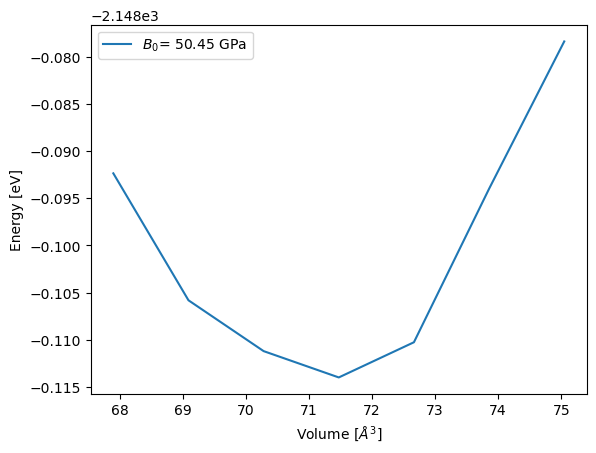

In [25]:
plt.plot(fit_dict["volume"], fit_dict["energy"], label="$B_0$= %0.2f GPa" % fit_dict["bulkmodul_eq"])
plt.xlabel("Volume [$\AA^3$]")
plt.ylabel("Energy [eV]")
plt.legend()

### FluxJobExecutor
In analogy to the [FluxClusterExecutor](https://executorlib.readthedocs.io/en/latest/2-hpc-cluster.html#flux) the [FluxJobExecutor](https://executorlib.readthedocs.io/en/latest/3-hpc-job.html#flux) can be applied to distribute simulation within a given queuing system allocation. The calculation of the bulk modulus with [quantum espresso](https://www.quantum-espresso.org) is implemented in the same way.

In [26]:
from executorlib import FluxJobExecutor

The for each strained structure a calculation task is submitted to the `FluxJobExecutor`. After the successful submission the current status of the flux queue is printed using `flux jobs -a`. Finally, the results are collected by gathering the [concurrent.futures.Future](https://docs.python.org/3/library/concurrent.futures.html#future-objects) objects.

In [27]:
future_dict = {}
with FluxJobExecutor(flux_executor_nesting=True) as exe:
    for k, v in task_loop_dict.items():
        os.makedirs(os.path.abspath(("strain_%0.2f" % k).replace(".", "_")), exist_ok=True)
        future_dict[k] = exe.submit(
            evaluate_with_quantum_espresso, 
            task_dict=v, 
            pseudopotentials=pseudopotentials, 
            kpts=(3, 3, 3), 
            resource_dict={
                "cores": 1,  # As an external executable is used the number of cores is set to one
                "threads_per_core": 2,  # For external executables the number of threads_per_core specifies the parallel execution
                "cwd": os.path.abspath(("strain_%0.2f" % k).replace(".", "_")),
            },
        )
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))
    result_dict = {
        k: f.result() 
        for k, f in tqdm(future_dict.items())
    }
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))

['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '   ƒ49ujdneC jovyan   flux        R      1      1   0.936s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ujdneB jovyan   flux        R      1      1   0.936s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ugfp5V jovyan   flux        R      1      1   0.938s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ucDrEV jovyan   flux        R      1      1   0.952s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ucDrEU jovyan   flux        R      1      1   0.952s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ucDrET jovyan   flux        R      1      1   0.952s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49uNsxhM jovyan   flux        R      1      1   0.953s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒirmeunP jovyan   jovyan     CD      1      1   4.126m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒikL42

100%|██████████| 7/7 [03:54<00:00, 33.53s/it] 


['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '   ƒ49ucDrEV jovyan   flux       CD      1      1   3.939m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ucDrEU jovyan   flux       CD      1      1   2.883m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ucDrET jovyan   flux       CD      1      1   2.059m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ujdneB jovyan   flux       CD      1      1   1.856m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ugfp5V jovyan   flux       CD      1      1   1.596m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49uNsxhM jovyan   flux       CD      1      1     1.5m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '   ƒ49ujdneC jovyan   flux       CD      1      1   26.23s '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒirmeunP jovyan   jovyan     CD      1      1   4.126m '
 'jupyter-janj-lanl-executorlib-tutorial-9ce2an8u',
 '    ƒikL42

The resulting energies for the different volumes are fitted using a 3rd order polynomial to derive the bulk modulus as second derivative multiplied by the equilibrium volume.

In [28]:
fit_dict = analyse_results_for_energy_volume_curve(
    output_dict={"energy": result_dict},
    task_dict=task_dict,
    fit_type="polynomial",
    fit_order=3,
)

The final energy volume curve plot summarizes the results of this calculation.

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2710/4024930470.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Volume [$\AA^3$]")


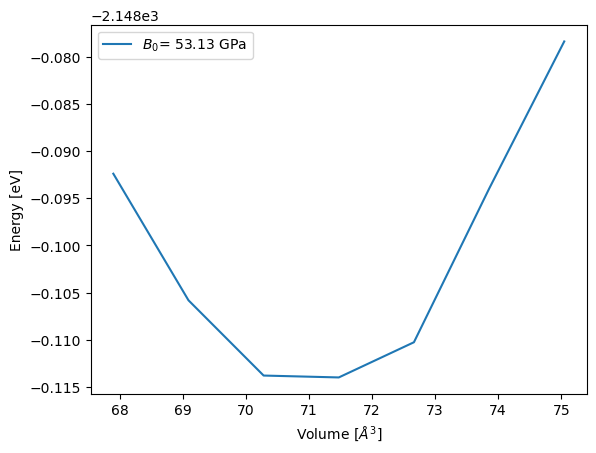

In [29]:
plt.plot(fit_dict["volume"], fit_dict["energy"], label="$B_0$= %0.2f GPa" % fit_dict["bulkmodul_eq"])
plt.xlabel("Volume [$\AA^3$]")
plt.ylabel("Energy [eV]")
plt.legend()